In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/motor-insurance.csv")

df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'


In [6]:
df = df.rename(columns={
    "DrivAge": "Age",
    "Area": "Region"
})
df.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'Region', 'VehPower', 'VehAge', 'Age',
       'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Region      678013 non-null  str    
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   Age         678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  str    
 9   VehGas      678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB


In [8]:
df.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,Age,BonusMalus,Density
count,6.780130e+05,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000
mean,2.621857e+06,0.053247,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405
std,1.641783e+06,0.240117,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157951e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272152e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046274e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In [9]:
df["ClaimNb"].value_counts()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
11         3
5          2
6          1
8          1
16         1
9          1
Name: count, dtype: int64

In [10]:
required_cols = ["Age","VehAge","VehPower","Exposure","ClaimNb"]

df = df.dropna(subset=required_cols).copy()
df = df[df["Exposure"] > 0]

In [11]:
df["Age"] = df["Age"].clip(lower=18, upper=90)
df["VehAge"] = df["VehAge"].clip(lower=0, upper=30)

In [12]:
df["claim_frequency"] = df["ClaimNb"] / df["Exposure"]

In [13]:
df["age_band"] = pd.cut(
    df["Age"],
    bins=[17,25,35,45,55,65,100],
    labels=["18-25","26-35","36-45","46-55","56-65","65+"]
)

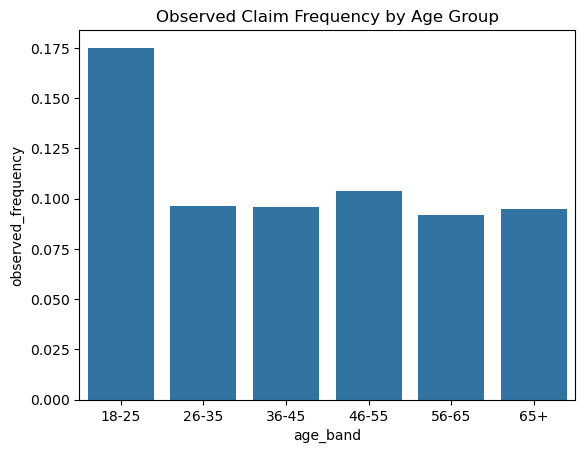

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

age_freq = df.groupby("age_band").apply(
    lambda x: x["ClaimNb"].sum()/x["Exposure"].sum()
).reset_index(name="observed_frequency")

sns.barplot(data=age_freq, x="age_band", y="observed_frequency")
plt.title("Observed Claim Frequency by Age Group")
plt.show()

In [16]:
plt.savefig("../output/figures/claim_frequency_by_age_band.png")

<Figure size 640x480 with 0 Axes>

In [20]:
import statsmodels.api as sm
import numpy as np
model_df = df[["Age","VehAge","VehPower","Exposure","ClaimNb"]].copy()

X = model_df[["Age","VehAge","VehPower"]]
X = sm.add_constant(X)

y = model_df["ClaimNb"]

model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=np.log(model_df["Exposure"])
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678009
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4599e+05
Date:                Mon, 16 Mar 2026   Deviance:                   2.2265e+05
Time:                        13:49:10   Pearson chi2:                 1.84e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.002698
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8012      0.026    -70.582      0.0

In [21]:
df["predicted_claims"] = model.predict(
    X,
    offset=np.log(model_df["Exposure"])
)

df["predicted_frequency"] = df["predicted_claims"] / df["Exposure"]

In [22]:
average_claim_cost = 3000

df["estimated_premium"] = df["predicted_frequency"] * average_claim_cost

In [23]:
segment = df.groupby("age_band").agg(
    avg_frequency=("predicted_frequency","mean"),
    avg_premium=("estimated_premium","mean")
).reset_index()

segment

,age_band,avg_frequency,avg_premium
0,18-25,0.110828,332.482893
1,26-35,0.111075,333.225892
2,36-45,0.105882,317.646624
3,46-55,0.101993,305.979945
4,56-65,0.099240,297.719014
5,65+,0.091908,275.725376


In [28]:
segment.to_csv("../output/segment_summary.csv",index=False)